In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys, os

# Configuracion de ruta para importar src
sys.path.append(os.path.abspath(os.path.join('..')))
from src.models_arima import fit_custom_arima, run_ljung_box

**Preparación Serie Temporal**

In [2]:
# Carga datos
df = pd.read_csv('../data/bitcoin_nasdaq_extended_py.csv')
df['Date'] = pd.to_datetime(df['Date'])
df = df.set_index('Date')
df = df.resample('MS').first()

# Rellenamos missings si los hubiera con los valores dia anterior y eliminamos nulos finales (caso: primer valor)
df = df.ffill().dropna()

ts_btc = df['btc']
ts_nasdaq = df['nasdaq']
ts_fed = df['fed_rate']

**Modelado de ARIMA y ARIMAX**

In [3]:
# Modelo ARIMA Univariante 
modelo_arima = fit_custom_arima(ts_btc)
print("--- Resumen ARIMA Base ---")
print(modelo_arima.summary())

# Modelo ARIMAX (Multivariante)
xreg_actual = df[['nasdaq', 'fed_rate']]
modelo_arimax = fit_custom_arima(ts_btc, exog=xreg_actual)
print("\n--- Resumen ARIMAX ---")
print(modelo_arimax.summary())

--- Resumen ARIMA Base ---
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  122
Model:               SARIMAX(2, 1, 2)   Log Likelihood               -1211.475
Date:                Fri, 13 Mar 2026   AIC                           2434.950
Time:                        09:49:36   BIC                           2451.725
Sample:                    01-01-2015   HQIC                          2441.763
                         - 02-01-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept    647.2051   2462.623      0.263      0.793   -4179.447    5473.857
ar.L1         -1.7491      0.087    -20.166      0.000      -1.919      -1.579
ar.L2         -0.8134    

**Comparación y Diagnóstico**

In [4]:
# Tabla Comparativa AIC
results_df = pd.DataFrame({
    'Modelo': ['ARIMA (Univariante)', 'ARIMAX (Multivariante)'],
    'AIC': [modelo_arima.aic(), modelo_arimax.aic()],
    'Especificacion': [str(modelo_arima.order), str(modelo_arimax.order)]
})
display(results_df)

# Test Ljung-Box sobre residuos de ARIMAX
p, d, q = modelo_arimax.order
lb_res = run_ljung_box(modelo_arimax.resid(), lags=24, df_adj=p+q)
display(lb_res)

,Modelo,AIC,Especificacion
0,ARIMA (Univariante),2434.949925,"(2, 1, 2)"
1,ARIMAX (Multivariante),2430.842549,"(4, 0, 0)"


,lb_stat,lb_pvalue
24,13.53199,0.853411


**Predicción dinámica 12 meses**

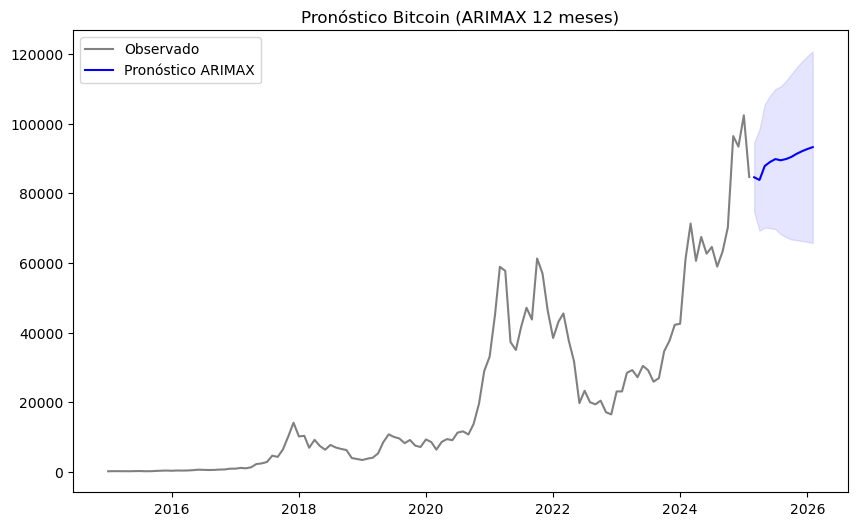

In [5]:
horizonte = 12

# Predicción del futuro del NASDAQ y FED
fit_nasdaq_fut = fit_custom_arima(ts_nasdaq)
fit_fed_fut = fit_custom_arima(ts_fed)

futuro_nasdaq = fit_nasdaq_fut.predict(n_periods=horizonte)
futuro_fed = fit_fed_fut.predict(n_periods=horizonte)

# Creación del xreg futuro
xreg_futuro = pd.DataFrame({
    'nasdaq': futuro_nasdaq.values,
    'fed_rate': futuro_fed.values
}, index=pd.date_range(start=ts_btc.index[-1] + pd.offsets.MonthBegin(1), periods=horizonte, freq='MS'))

# Pronóstico final ARIMAX
forecast_values, conf_int = modelo_arimax.predict(
    n_periods=horizonte, 
    X=xreg_futuro, 
    return_conf_int=True
)

# Visualización
plt.figure(figsize=(10,6))
plt.plot(ts_btc, label='Observado', color='gray')
plt.plot(xreg_futuro.index, forecast_values, label='Pronóstico ARIMAX', color='blue')
plt.fill_between(xreg_futuro.index, conf_int[:, 0], conf_int[:, 1], color='blue', alpha=0.1)
plt.title('Pronóstico Bitcoin (ARIMAX 12 meses)')
plt.legend()
plt.show()